In [1]:
import phaseco as pc
import os
# Replace this with the path to your otocoherence repo
os.chdir(r"C:\Users\setht\Dropbox\Citadel\GitHub\otocoherence\scripts")
from helper_funcs import *

In [2]:
%load_ext autoreload
%autoreload
import matplotlib.pyplot as plt
import phaseco as pc

In [3]:
# Folders
otocoherence_dir = r"C:\Users\setht\Dropbox\Citadel\GitHub\otocoherence"
phaseco_dir = r"C:\Users\setht\Dropbox\Citadel\GitHub\phaseco"

pkl_folder = os.path.join('pickles', 'soae')
tau_pkl_folder = 'pickles'
docs_figures_folder = os.path.join('docs', 'assets')
os.chdir(phaseco_dir)
os.makedirs(docs_figures_folder, exist_ok=True)
os.chdir(otocoherence_dir)



In [4]:
# Colors
anole_color = "#07586E"
human_color = "#8C60B3"

# Fontsize / labels
fontsize = 34
labelpad = 20

In [5]:
"PARAMETERS"
# WF pre-processing parameters
# filter_meth = {
#     "type": "kaiser",
#     "cf": 300,
#     "df": 50,
#     "rip": 100,
# }  # High pass filter cutoff freq, transition band width, and max allowed ripple (in dB)
filter_meth=None
wf_len_s = 60  # Will crop waveform to this length (in seconds)
scale = True  # Scale the waveform (only actually scales if we know the right scaling constant, which is only Anoles and Humans)

# Coherence Parameters
hop_s = 0.01
win_type = "flattop"
rho=1.0
win_meth = {"method": "rho", "rho": rho, "win_type":win_type}
pw = False
bw = 50
xi_min_s = 0.001
delta_xi_s = 0.001
nfft = 2**14
const_N_pd = 0


# Start building LCC kwargs dict with constants
lcc_kwargs ={
        'wf_len_s':wf_len_s,
        'filter_meth':filter_meth,        
        'pw':pw,
        'xi_min_s':xi_min_s,
        'win_meth':win_meth,
        "nfft": nfft,
        "pkl_folder": pkl_folder,
}






0.07448979591836735
Processing 'pickles\soae\Owl 3, PW=False, rho=1.0, Flattop, hop=441, tau=3285, filter=None, xi_max=100ms, nfft=16384, N_pd=max, DM=True, wf_len=60s, wf=owl_TAG4learSOAEwf1 (Colossogram).pkl'


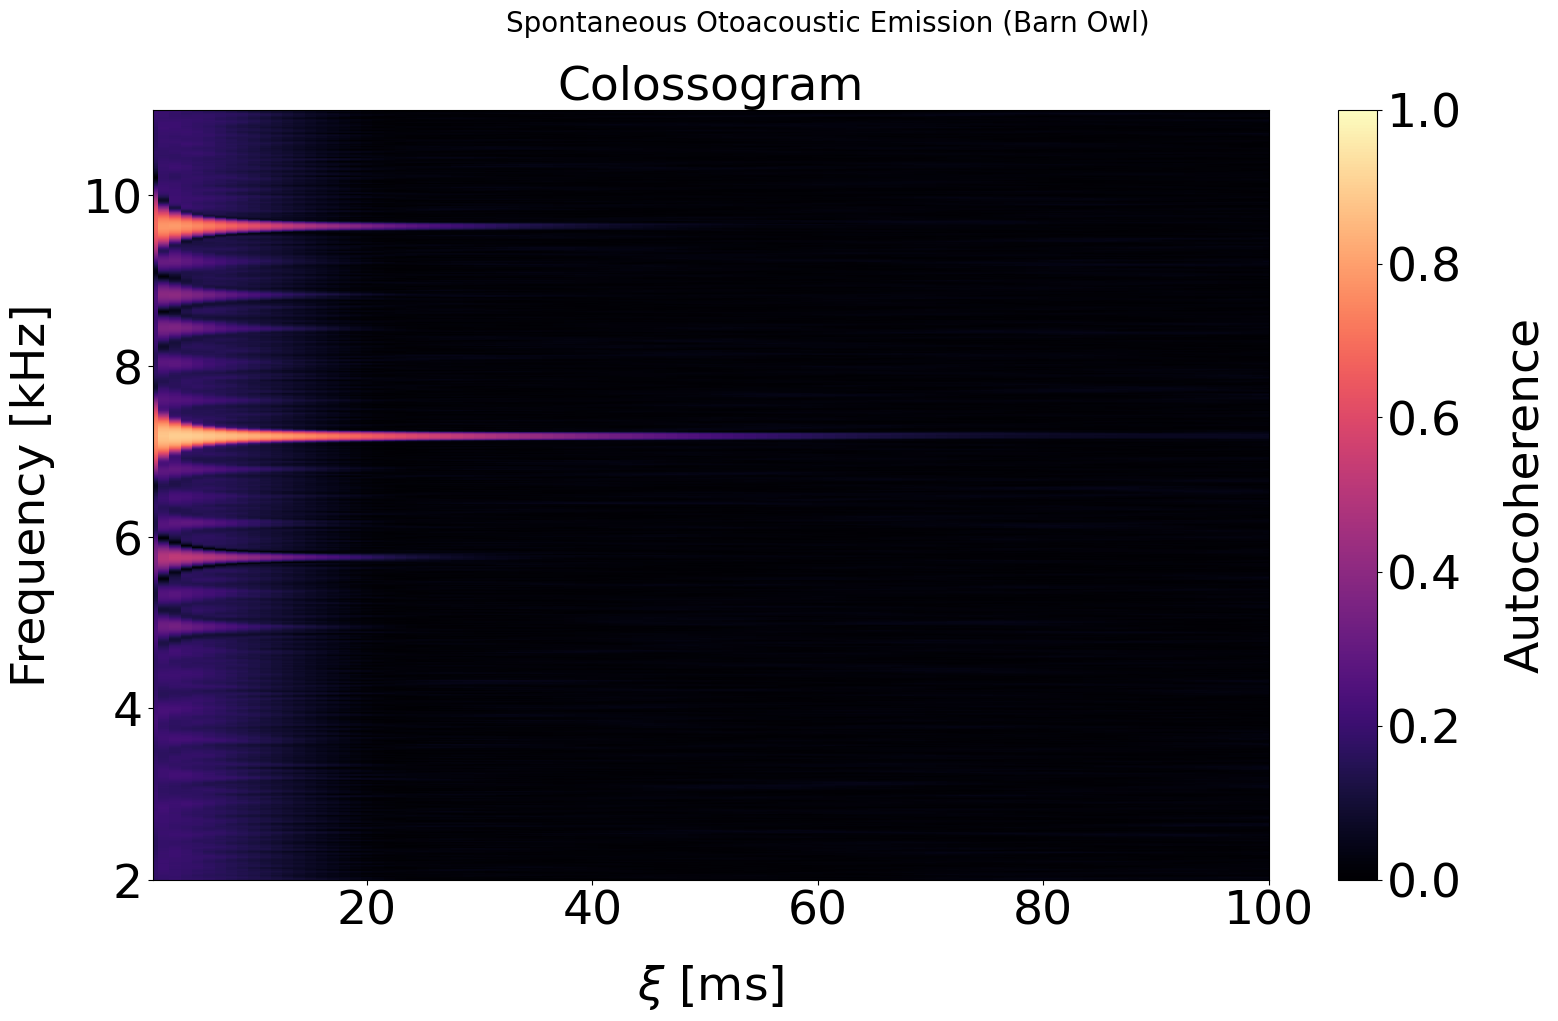

In [8]:
"Owl Colossogram"
os.chdir(otocoherence_dir)
# Choose subject
species = "Owl"
wf_idx = 3
# Get waveform
wf, wf_fn, fs, good_peak_freqs, bad_peak_freqs = get_wf(
    species=species,
    wf_idx=wf_idx,
)

# Get/set a few more params
xi_max_s = 0.1
tau = get_precalc_tau_from_bw(bw, fs, win_type, tau_pkl_folder)
print(tau/fs)

# Load Colossogram
cgram_dict = load_calc_colossogram(
    **(
        lcc_kwargs
        | {
            "xi_max_s": xi_max_s,
            "species": species,
            "fs": fs,
            "tau": tau,
            "hop": int(round(hop_s * fs)),
            "wf": wf,
            "wf_idx": wf_idx,
            "wf_fn": wf_fn,
        }
    )
)


# Load everything that wasn't explicitly "saved" in the filename
colossogram = cgram_dict["colossogram"]
fn_id = cgram_dict["fn_id"]
win_meth_str = cgram_dict["win_meth_str"]
method_id = cgram_dict["method_id"]
filter_str = cgram_dict["filter_str"]
N_pd_str = pc.get_N_pd_str(const_N_pd, cgram_dict["N_pd_min"], cgram_dict["N_pd_max"])
f = cgram_dict["f"]
xis_s = cgram_dict["xis_s"]
good_peak_idxs = np.argmin(np.abs(f[:, None] - good_peak_freqs[None, :]), axis=0)
method_id = rf"[$\tau$={(tau/fs)*1000:.2f}ms]   [PW={pw}]   [{win_meth_str}]   [Hop={hop_s*1000:.1f}ms]   [{N_pd_str}]   [nfft={nfft}]"
suptitle = (
    rf"[{species} {wf_idx}]   [{wf_fn}]   [HPBW={bw}Hz]   {method_id}   [{filter_str}]"
)

# MAKE PLOT
plt.figure(figsize=(18, 10))
cbar = pc.plot_colossogram(
    cgram_dict,
    cmap="magma",
    return_cbar=True
)
# Set Chris' requested fontsizes
ax = plt.gca()


ax.set_xlabel(r"$\xi$ [ms]", labelpad=labelpad, fontsize=fontsize)
ax.set_ylabel("Frequency [kHz]", labelpad=labelpad, fontsize=fontsize)

ax.tick_params('both', labelsize=fontsize)
cbar.ax.yaxis.label.set_fontsize(fontsize)
cbar.ax.tick_params(labelsize=fontsize)
cbar.ax.set_ylabel("Autocoherence")

plt.ylim(2, 11)
xmin=0.001
plt.xlim(1, 100)
    
plt.title(f"Colossogram", fontsize=fontsize)
plt.suptitle(f"Spontaneous Otoacoustic Emission (Barn Owl)", fontsize=20)
os.chdir(phaseco_dir)
plt.savefig(os.path.join(docs_figures_folder, f'Owl Colossogram ({wf_fn.split('.')[0]}).jpg'),dpi=500)

Processing 'pickles\soae\Owl 3, PW=False, rho=1.0, Flattop, hop=441, tau=3285, filter=None, xi_max=100ms, nfft=16384, N_pd=max, DM=True, wf_len=60s, wf=owl_TAG4learSOAEwf1 (Colossogram).pkl'
Initializing fit on 9633Hz autocoherence decay...
One peak found in first 26ms of xi, starting fit here
Fitting...
Fit succeeded on first try!


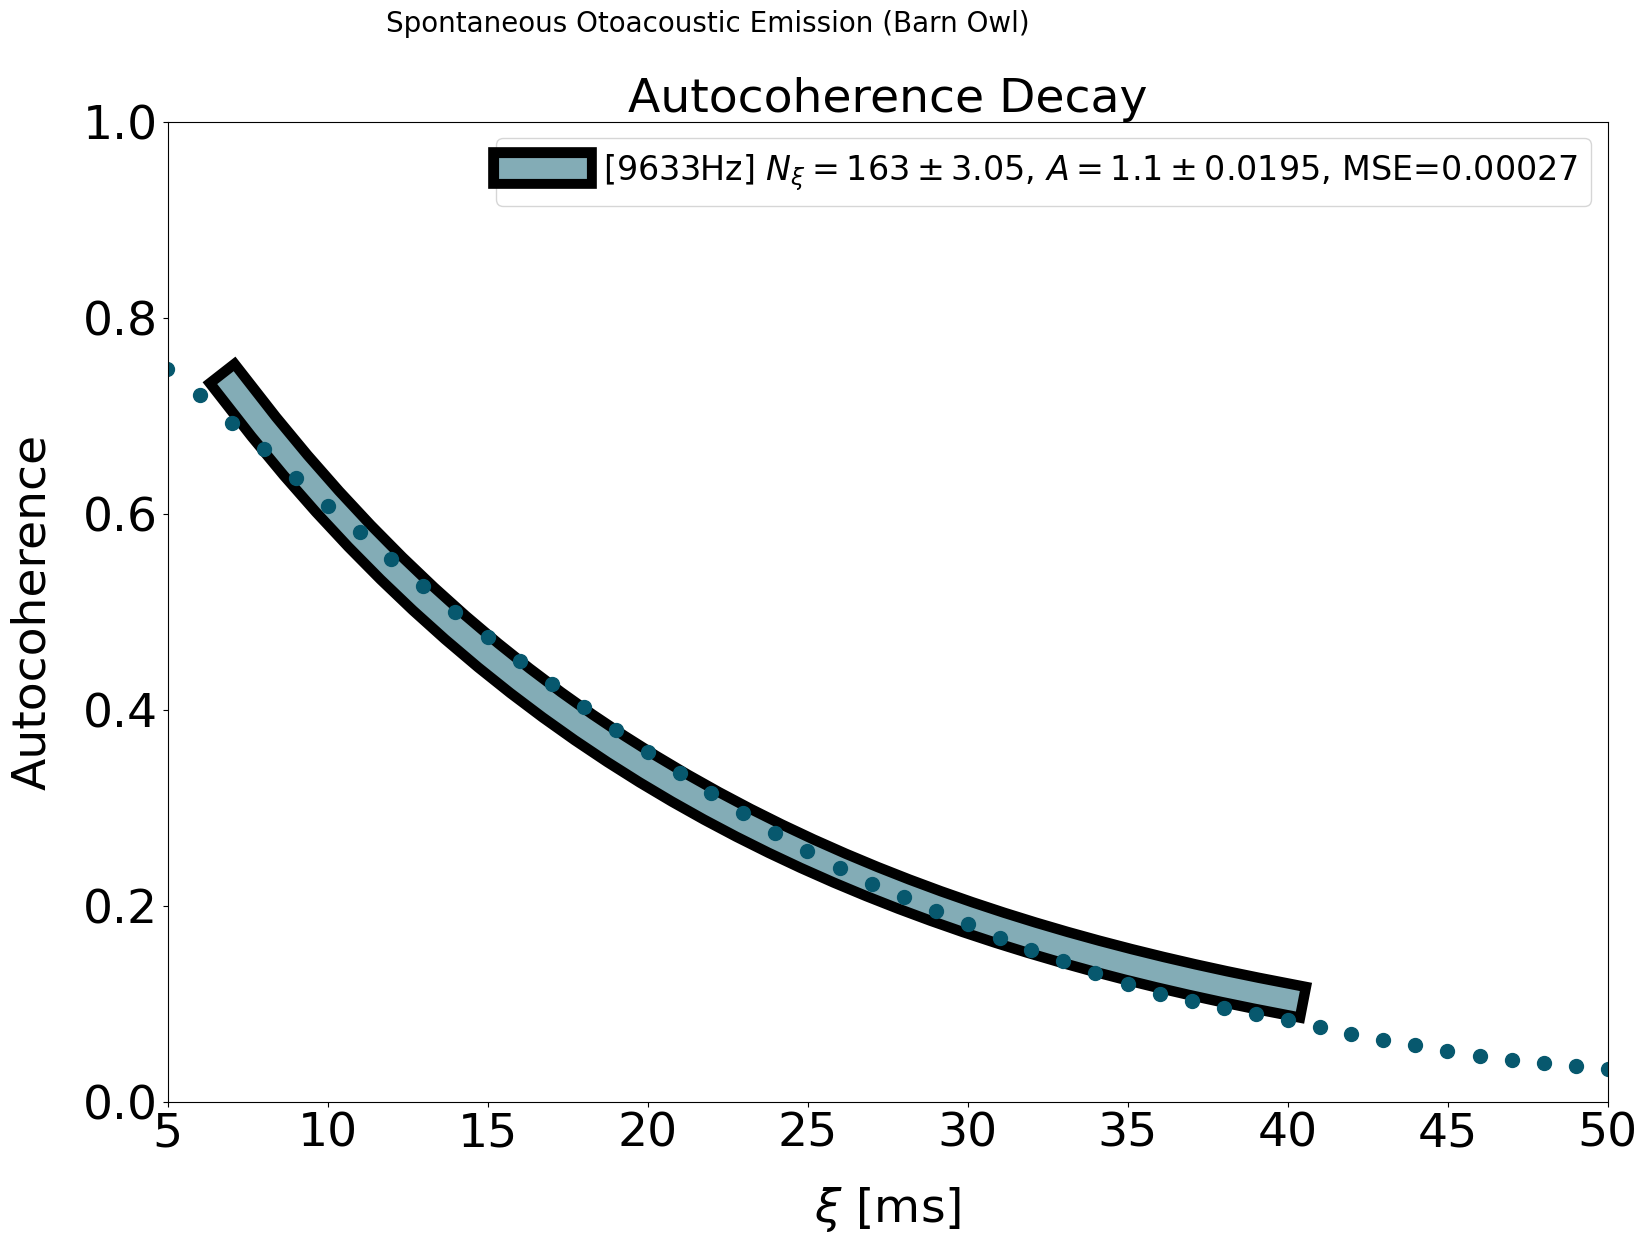

In [10]:
"Owl N_xi Fit"

os.chdir(otocoherence_dir)

# Choose subject
species = "Owl"
wf_idx = 3


# Get waveform
wf, wf_fn, fs, good_peak_freqs, bad_peak_freqs = get_wf(
    species=species,
    wf_idx=wf_idx,
)

# Get/set a few more params
xi_max_s = 0.1
tau = get_precalc_tau_from_bw(bw, fs, win_type, tau_pkl_folder)

# Load Colossogram
cgram_dict = load_calc_colossogram(
    **(
        lcc_kwargs
        | {
            "xi_max_s": xi_max_s,
            "species": species,
            "fs": fs,
            "tau": tau,
            "hop": int(round(hop_s * fs)),
            "wf": wf,
            "wf_idx": wf_idx,
            "wf_fn": wf_fn,
        }
    )
)


# Load everything that wasn't explicitly "saved" in the filename
colossogram = cgram_dict["colossogram"]
fn_id = cgram_dict["fn_id"]
win_meth_str = cgram_dict["win_meth_str"]
method_id = cgram_dict["method_id"]
filter_str = cgram_dict["filter_str"]
N_pd_str = pc.get_N_pd_str(const_N_pd, cgram_dict["N_pd_min"], cgram_dict["N_pd_max"])
f = cgram_dict["f"]
xis_s = cgram_dict["xis_s"]
good_peak_idxs = np.argmin(np.abs(f[:, None] - good_peak_freqs[None, :]), axis=0)
method_id = rf"[$\tau$={(tau/fs)*1000:.2f}ms]   [PW={pw}]   [{win_meth_str}]   [Hop={hop_s*1000:.1f}ms]   [{N_pd_str}]   [nfft={nfft}]"
suptitle = (
    rf"[{species} {wf_idx}]   [{wf_fn}]   [HPBW={bw}Hz]   {method_id}   [{filter_str}]"
)

# Get N_xi_fit
f0 = good_peak_freqs[3]

# Fitting Parameters
A_max = np.inf  # 1 or np.inf
A_const = False  # Fixes the amplitude of the decay at 1

N_xi, N_xi_dict = pc.get_N_xi(
    cgram_dict,
    f0,
)

# MAKE PLOT
fig = plt.figure(figsize=(18, 14))
ax = fig.add_axes([0.2, 0.2, 0.8, 0.7])  # [left, bottom, width, height] in figure fraction
pc.plot_N_xi_fit(N_xi_dict, color=anole_color, plot_noise_floor=False, lw_fit=15, lw_stroke=15, s_signal=100)


ax.set_xlabel(r"$\xi$ [ms]", labelpad=labelpad, fontsize=fontsize)
ax.set_ylabel(r"Autocoherence", labelpad=labelpad, fontsize=fontsize)
ax.set_title("")
ax.legend(fontsize=fontsize-10)

ax.tick_params('both', labelsize=fontsize)

plt.xlim(5, 50)
    
plt.title(f"Autocoherence Decay", fontsize=fontsize)
plt.suptitle(f"Spontaneous Otoacoustic Emission (Barn Owl)", fontsize=20)
os.chdir(phaseco_dir)
plt.savefig(os.path.join(docs_figures_folder, f'Owl N_xi Fit [{f0:.0f}Hz] ({wf_fn.split('.')[0]}).png'), dpi=500)